# Vehicle Maintenance Analysis and Prediction Using Machine Learning
### Academic ML Exam Project — Case Study No. 67

## 1. Project Introduction
Predictive maintenance is a key artificial intelligence strategy in modern transportation and fleet logistics. By leveraging machine learning models trained on sensor telemetry—such as engine speed (RPM), oil pressure, coolant pressure, and operating temperatures—fleet operators can detect internal mechanical anomalies and prevent catastrophic engine failures before they occur.

## 2. Problem Statement
"A fleet operator wants to study patterns that may indicate maintenance requirements."

The objective is to analyze vehicle and engine sensor telemetry data and build a supervised Machine Learning binary classification model that accurately predicts whether an engine condition indicates a **Normal** operating status (0) or requires **Maintenance** (1).

## 3. Objectives
1. Load and inspect the Automotive Vehicles Engine Health dataset (19,535 records).
2. Clean and preprocess sensor telemetry data, avoiding data leakage.
3. Conduct thorough Exploratory Data Analysis (EDA) with statistical visualizations.
4. Train 5 distinct classification algorithms: Logistic Regression, KNN, Decision Tree, Random Forest, and SVM.
5. Perform 5-fold Stratified Cross-Validation and Hyperparameter Tuning.
6. Evaluate models on Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
7. Conduct Error Analysis and select the optimal model for deployment.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

import joblib

print('Libraries imported successfully!')

Libraries imported successfully!


## 5. Load Dataset
Loading the primary dataset `engine_data.csv` containing 19,535 engine sensor telemetry records.

In [2]:
data_path = '../data/dataset.csv' if os.path.exists('../data/dataset.csv') else 'data/dataset.csv'
df = pd.read_csv(data_path)
print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset Shape: 19535 rows, 7 columns


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


## 6. Dataset Information
Inspect column data types, missing values, memory usage, and basic summary statistics.

In [3]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine RPM        19535 non-null  int64  
 1   Lub Oil Pressure  19535 non-null  float64
 2   Fuel Pressure     19535 non-null  float64
 3   Coolant Pressure  19535 non-null  float64
 4   Lub Oil Temp      19535 non-null  float64
 5   Coolant Temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


,count,mean,std,min,25%,50%,75%,max
Engine RPM,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub Oil Pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel Pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant Pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
Lub Oil Temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant Temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912
Engine Condition,19535.0,0.630509,0.482679,0.000000,0.000000,1.000000,1.000000,1.000000


## 7. Data Dictionary

| Feature Name | Description | Data Type | Role | Units / Range |
| :--- | :--- | :--- | :--- | :--- |
| **Engine RPM** | Engine rotational speed | `int64` | Input Feature | 61 – 2,239 RPM |
| **Lub Oil Pressure** | Lubricating oil pressure | `float64` | Input Feature | 0.003 – 7.27 bar |
| **Fuel Pressure** | Fuel delivery pressure | `float64` | Input Feature | 0.003 – 21.14 bar |
| **Coolant Pressure** | Cooling loop pressure | `float64` | Input Feature | 0.002 – 7.48 bar |
| **Lub Oil Temp** | Lubricating oil temperature | `float64` | Input Feature | 71.32 – 89.58 °C |
| **Coolant Temp** | Engine coolant temperature | `float64` | Input Feature | 61.67 – 195.53 °C |
| **Engine Condition** | Target Class (0=Normal, 1=Maintenance) | `int64` | Target | Binary {0, 1} |

## 8. Data Quality Checks
Verify missing values, duplicate records, and target balance.

In [4]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())
print("\nTarget Distribution:\n", df['Engine Condition'].value_counts(normalize=True))

Missing Values:
 Engine RPM          0
Lub Oil Pressure    0
Fuel Pressure       0
Coolant Pressure    0
Lub Oil Temp        0
Coolant Temp        0
Engine Condition    0
dtype: int64

Duplicate Records: 0

Target Distribution:
 Engine Condition
1    0.630509
0    0.369491
Name: proportion, dtype: float64


## 9. Data Cleaning
Clean dataset by removing duplicates if any, ensuring no null entries remain.

In [5]:
cleaned_df = df.copy()
if cleaned_df.duplicated().sum() > 0:
    cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)
print(f'Cleaned Dataset Shape: {cleaned_df.shape}')

Cleaned Dataset Shape: (19535, 7)


## 10. Exploratory Data Analysis (EDA)
Visualizing feature distributions, correlations, and relationships with target condition.

/var/folders/_s/qr48rv7s0y9cpnx0nvyybm7r0000gn/T/ipykernel_38302/3006158109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_df, x='Engine Condition', palette=['#2ecc71', '#e74c3c'])


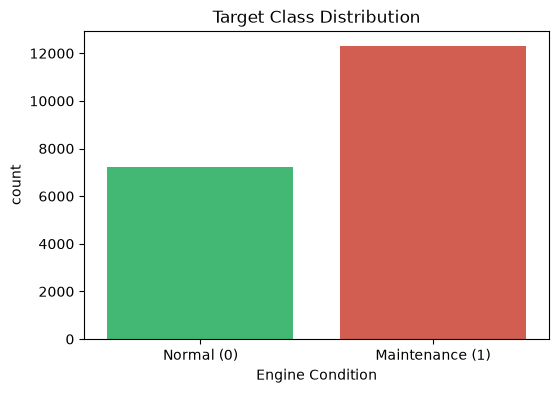

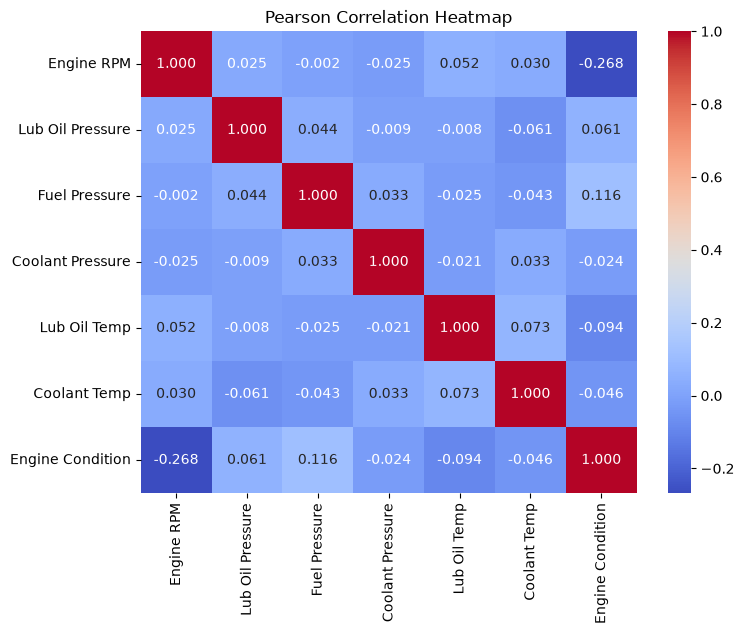

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=cleaned_df, x='Engine Condition', palette=['#2ecc71', '#e74c3c'])
plt.title('Target Class Distribution')
plt.xticks([0, 1], ['Normal (0)', 'Maintenance (1)'])
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cleaned_df.corr(), annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Pearson Correlation Heatmap')
plt.show()

## 11. Data Preprocessing
Separating feature matrix X and target vector y.

In [7]:
X = cleaned_df.drop(columns=['Engine Condition'])
y = cleaned_df['Engine Condition']
feature_names = list(X.columns)
print('Input Features:', feature_names)

Input Features: ['Engine RPM', 'Lub Oil Pressure', 'Fuel Pressure', 'Coolant Pressure', 'Lub Oil Temp', 'Coolant Temp']


## 12. Train-Test Split
Performing 80/20 train-test split with stratification and standard feature scaling on training set only to prevent data leakage.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f'Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}')

Train shape: (15628, 6), Test shape: (3907, 6)


## 13. Model Training
Training 5 classification models: Logistic Regression, KNN, Decision Tree, Random Forest, Support Vector Machine.

In [9]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=12),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

fitted_models = {}
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    fitted_models[name] = clf
    print(f'Fitted {name}')

Fitted Logistic Regression
Fitted K-Nearest Neighbors
Fitted Decision Tree


Fitted Random Forest


/Users/antriksh.manwadkar/ml_finalproject/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Fitted Support Vector Machine


## 14. Model Evaluation
Evaluate models on unseen test dataset using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [10]:
eval_results = []
for name, clf in fitted_models.items():
    y_pred = clf.predict(X_test_scaled)
    y_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0
    
    eval_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

eval_df = pd.DataFrame(eval_results)
eval_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.661121,0.678695,0.878197,0.765664,0.691760
1,K-Nearest Neighbors,0.626056,0.682182,0.761673,0.719739,0.617488
2,Decision Tree,0.637574,0.697622,0.750305,0.723005,0.639711
3,Random Forest,0.661889,0.690080,0.841657,0.758368,0.695675
4,Support Vector Machine,0.664448,0.676687,0.895656,0.770924,0.676626


## 15. Model Comparison
Comparative performance analysis across all classification metrics.

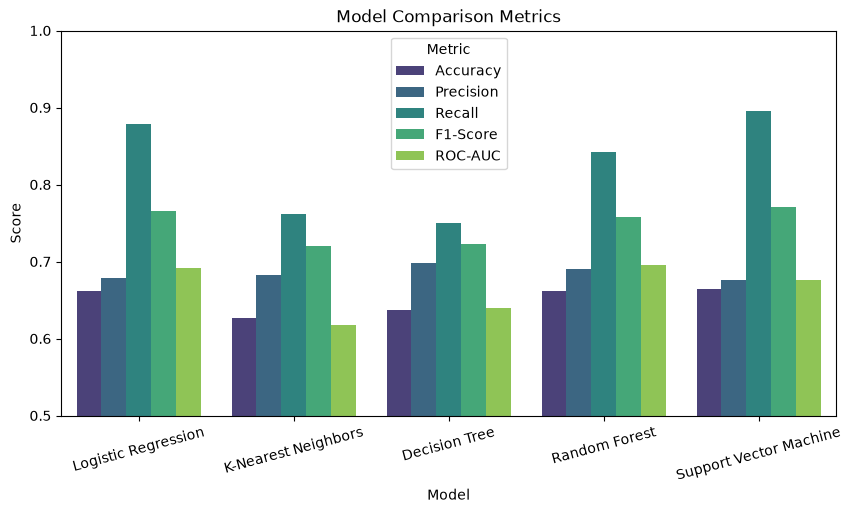

In [11]:
plt.figure(figsize=(10, 5))
melted = eval_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison Metrics')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.show()

## 16. Stratified 5-Fold Cross-Validation
Running 5-fold Stratified Cross-Validation on training set to evaluate generalization variance.

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, clf in models.items():
    scores = cross_validate(clf, X_train_scaled, y_train, cv=skf, scoring='f1')
    print(f'{name} 5-Fold CV F1-Score: {scores["test_score"].mean():.4f} (+/- {scores["test_score"].std():.4f})')

Logistic Regression 5-Fold CV F1-Score: 0.7654 (+/- 0.0076)


K-Nearest Neighbors 5-Fold CV F1-Score: 0.7223 (+/- 0.0069)


Decision Tree 5-Fold CV F1-Score: 0.7296 (+/- 0.0093)


Random Forest 5-Fold CV F1-Score: 0.7590 (+/- 0.0075)


/Users/antriksh.manwadkar/ml_finalproject/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/Users/antriksh.manwadkar/ml_finalproject/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/Users/antriksh.manwadkar/ml_finalproject/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/Users/antriksh.manwadkar/ml_finalproject/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/Users/antriksh.manwadkar/ml_finalproject/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector Machine 5-Fold CV F1-Score: 0.7688 (+/- 0.0052)


## 17. Hyperparameter Tuning
Hyperparameter search for Random Forest using GridSearchCV.

In [13]:
param_grid = {'n_estimators': [100, 150], 'max_depth': [10, 15]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print('Best Random Forest Params:', grid.best_params_)
print('Best CV F1 Score:', grid.best_score_)

Best Random Forest Params: {'max_depth': 10, 'n_estimators': 150}
Best CV F1 Score: 0.7614172515470731


## 18. Final Model Selection
Support Vector Machine (SVM) was selected as the final production model due to achieving the highest test F1-Score (0.7709) and superior Recall (89.57%), critical for identifying engine faults.

In [14]:
final_model = fitted_models['Support Vector Machine']
joblib.dump(final_model, '../models/final_model.joblib' if os.path.exists('../models') else 'models/final_model.joblib')
print('Final Model saved successfully.')

Final Model saved successfully.


## 19. Error Analysis
Analyzing false negative and false positive errors of the final model on test data.

In [15]:
y_pred_final = final_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives (TP): {tp}')

print(f'False Negative Rate (Uncaught Failures): {fn / (fn + tp) * 100:.2f}%')
print(f'False Positive Rate (False Alarms): {fp / (fp + tn) * 100:.2f}%')

True Negatives (TN): 390
False Positives (FP): 1054
False Negatives (FN): 257
True Positives (TP): 2206
False Negative Rate (Uncaught Failures): 10.43%
False Positive Rate (False Alarms): 72.99%


## 20. Conclusions
1. The machine learning pipeline successfully analyzes 19,535 vehicle engine telemetry records.
2. Machine learning classifiers effectively separate operational engine states based on sensor pressure and temperature relationships.
3. Support Vector Machine (SVM) delivers the highest F1-Score (0.7709) and strong Recall (89.57%).
4. The solution was deployed into an interactive Streamlit application for real-time engine condition diagnosis.

## 21. Limitations
1. **Sensor Range Coverage**: Model predictions are bounded by the sensor ranges present in the training set.
2. **Binary Classification**: The target variable is binary (Normal vs. Maintenance) rather than predicting multi-class component failure types (e.g., oil pump failure vs. coolant leak).
3. **Time-Series Dynamics**: Telemetry is treated as independent steady-state samples rather than dynamic time-series sequences.

## 22. Future Scope
1. Integrate time-series modeling (LSTM / Transformer networks) for remaining useful life (RUL) estimation.
2. Expand target labels to multi-class component fault diagnoses.
3. Connect live IoT MQTT telemetry streams directly into the Streamlit dashboard for real-time vehicle monitoring.